# Imports

In [35]:

import sys

sys.path.insert(0, "../../operon-project/code/graph_api")
sys.path.insert(0, "../../operon-project/code/search_pipeline")

from graph_classes import Subgraph, ReferenceGraph, MergedGraph, Edge, Node
from graph_classes import nameddict, count_fg_occurence, read_meta_data, get_graph_id, get_subgraph_id, \
    has_existing_graph_builds, delete_file, load_modified_from_pickle_if_exists, reset_subgraph_and_delete_modified
from graph_classes import ABUNDANCE_DETECTION_LIMIT, TXT_POSTFIX, JSON_POSTFIX, PICKLE_POSTFIX, MODIFIED_POSTFIX
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from __future__ import annotations

import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt

## Load graphs from pfam_constrained_amr run

In [2]:


graphs_dir = Path('../data/runs/pfam_constrained_amr/window-size_10/min-contigs_3/min-domains-matched_1/graphs/')


def _load_single_subgraph_pkl(graph_folder: Path):
    pkls = sorted(graph_folder.glob("subgraph_*.pkl"))
    if len(pkls) != 1:
        raise RuntimeError(
            f"{graph_folder.name}: expected exactly 1 subgraph_*.pkl, found {len(pkls)} -> {[p.name for p in pkls]}")
    with pkls[0].open("rb") as f:
        return pickle.load(f)


graph_to_subgraph = {
    gf.name: _load_single_subgraph_pkl(gf)
    for gf in sorted(graphs_dir.glob("graph_*"))
    if gf.is_dir()
}

## Compute per-graph taxonomy majority summary

In [3]:
from __future__ import annotations

from collections import Counter
from typing import Optional, Tuple


def graph_taxonomy_summary(
        graph,  # expects something with .nodes: dict[id -> node] and node.taxonomy: dict
        tax_key: str = "gtdbtk_ann",
) -> Tuple[float, Optional[str]]:
    """
    Returns (percent_assigned_to_majority, majority_taxonomy_value or None).

    Rules:
    - Only count nodes where node.taxonomy has a non-empty value for tax_key.
    - Majority vote is computed over annotated nodes.
    - If there's a tie for top count -> error.
    - If no annotated nodes -> (0.0, None).
    - Percent is (top_count / total_nodes) * 100 (not / annotated_nodes).
    """
    nodes = list(getattr(graph, "nodes").values())
    total = len(nodes)

    if total == 0:
        return (0.0, None)

    vals = [
        (n.taxonomy.get(tax_key) if getattr(n, "taxonomy", None) else None)
        for n in nodes
    ]
    vals = [v for v in vals if v not in (None, "", {})]

    if not vals:
        return (0.0, None)

    counts = Counter(vals)
    (top_val, top_count) = counts.most_common(1)[0]

    # error if no strict majority among annotated nodes (tie for top)
    top_count_2 = counts.most_common(2)[1][1] if len(counts) > 1 else 0
    if top_count == top_count_2:
        raise RuntimeError(
            f"No unique majority for {tax_key}: {counts} in graph {graph.filepath}"
        )

    percent = (top_count / total) * 100.0
    return (percent, top_val)


# If you already built graph_to_subgraph (or graph_to_graph), create the dict:
graph_to_tax = {
    graph_id: graph_taxonomy_summary(g, tax_key="gtdbtk_ann")
    for graph_id, g in graph_to_subgraph.items()
}


## Plot histogram of taxonomy majority percentages

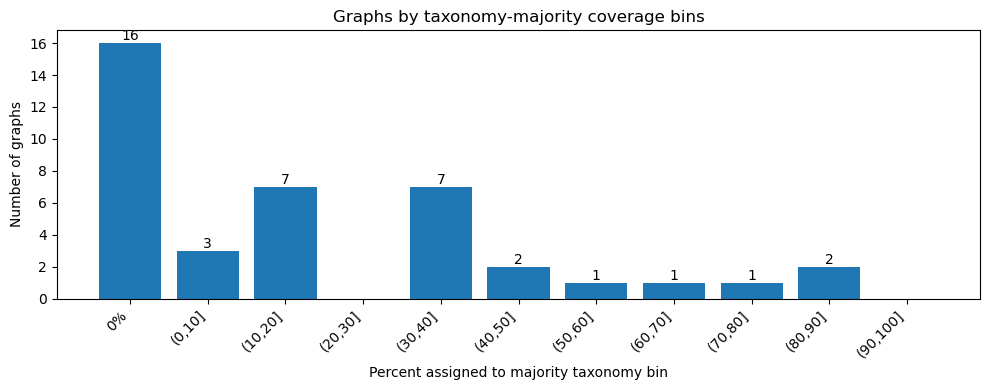

In [4]:

# Collect percentages
perc = np.array([v[0] for v in graph_to_tax.values()], dtype=float)

# Bins:
# - exact 0% as its own bin
# - (0,10], (10,20], ..., (90,100]
edges = np.arange(0, 101, 10)  # 0,10,...,100

zero_count = int(np.sum(perc == 0.0))

# assign positives into (0,10], (10,20], ... using right-closed bins
pos = perc[perc > 0.0]
# bin index: 1..10 (since edges length is 11); 1 corresponds to (0,10], 2 -> (10,20], ...
bin_idx = np.digitize(pos, edges, right=True)
counts = np.array([(bin_idx == i).sum() for i in range(1, len(edges))], dtype=int)

# Build labels
labels = ["0%"] + [f"({edges[i - 1]},{edges[i]}]" for i in range(1, len(edges))]

bar_counts = np.concatenate(([zero_count], counts))

# Plot
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, bar_counts)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Number of graphs")
ax.set_xlabel("Percent assigned to majority taxonomy bin")
ax.set_title("Graphs by taxonomy-majority coverage bins")

# annotate counts on bars (optional)
for xi, ci in zip(x, bar_counts):
    if ci > 0:
        ax.text(xi, ci, str(ci), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [5]:
def _get_tax_val(node, tax_key: str) -> str:
    tax = getattr(node, "taxonomy", None) or {}
    v = tax.get(tax_key, None)
    if v is None or v == "" or v == {}:
        return "unannotated"
    return str(v)


def per_graph_taxa_long_df(graph_to_subgraph: dict, tax_key: str = "gtdbtk_ann") -> pd.DataFrame:
    rows = []
    for graph_id, g in graph_to_subgraph.items():
        nodes = list(g.nodes.values())
        n_nodes = len(nodes)
        vals = [_get_tax_val(n, tax_key) for n in nodes]
        c = Counter(vals)

        for taxon, count in c.most_common():
            rows.append({
                "graph_id": graph_id,
                "n_nodes": n_nodes,
                "taxon": taxon,
                "count": count,
                "pct": (count / n_nodes * 100.0) if n_nodes else 0.0,
            })

    df = pd.DataFrame(rows)
    # rank within each graph
    df["rank_in_graph"] = df.groupby("graph_id")["count"].rank(method="first", ascending=False).astype(int)
    return df


df = per_graph_taxa_long_df(graph_to_subgraph, tax_key="gtdbtk_ann")

# Per-graph ranked view (what your supervisor asked for)
per_graph_ranked = {
    gid: list(zip(g["taxon"], g["count"]))
    for gid, g in df.sort_values(["graph_id", "count"], ascending=[True, False]).groupby("graph_id")
}

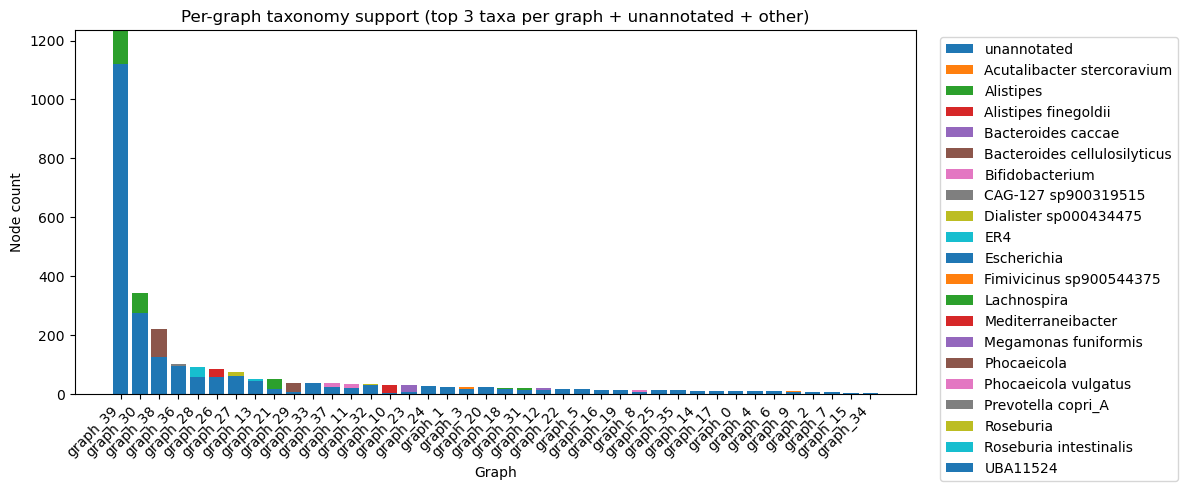

In [6]:
def plot_stacked_topk_per_graph(df: pd.DataFrame, top_k: int = 3):
    # Ensure stable graph order (by total nodes or by name)
    graph_order = (
        df[["graph_id", "n_nodes"]].drop_duplicates()
        .sort_values(["n_nodes", "graph_id"], ascending=[False, True])["graph_id"]
        .tolist()
    )

    # For each graph: keep top_k taxa (excluding "unannotated" or including it, your choice)
    # Here: keep top_k taxa among annotated taxa, but always keep "unannotated" as its own segment.
    parts = []
    for gid in graph_order:
        g = df[df["graph_id"] == gid].copy()
        n_nodes = int(g["n_nodes"].iloc[0]) if len(g) else 0

        unann = g[g["taxon"] == "unannotated"][["taxon", "count"]]
        ann = g[g["taxon"] != "unannotated"].sort_values("count", ascending=False)

        top = ann.head(top_k)[["taxon", "count"]]
        other_count = int(ann["count"].sum() - top["count"].sum())

        rows = []
        if len(unann):
            rows.append(("unannotated", int(unann["count"].iloc[0])))
        for t, c in top.itertuples(index=False):
            rows.append((t, int(c)))
        if other_count > 0:
            rows.append(("other", other_count))

        for t, c in rows:
            parts.append({"graph_id": gid, "taxon": t, "count": c, "n_nodes": n_nodes})

    plot_df = pd.DataFrame(parts)

    # Pivot to wide for stacked bars
    wide = plot_df.pivot_table(index="graph_id", columns="taxon", values="count", aggfunc="sum", fill_value=0)
    wide = wide.loc[graph_order]  # order graphs

    # Stack order: unannotated first, then taxa, then other last if present
    cols = list(wide.columns)
    ordered_cols = []
    if "unannotated" in cols:
        ordered_cols.append("unannotated")
    # keep remaining except "other"
    ordered_cols += [c for c in cols if c not in ("unannotated", "other")]
    if "other" in cols:
        ordered_cols.append("other")
    wide = wide[ordered_cols]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    bottoms = np.zeros(len(wide), dtype=float)
    x = np.arange(len(wide))

    for col in wide.columns:
        vals = wide[col].to_numpy()
        ax.bar(x, vals, bottom=bottoms, label=col)
        bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels(wide.index.tolist(), rotation=45, ha="right")
    ax.set_ylabel("Node count")
    ax.set_xlabel("Graph")
    ax.set_title(f"Per-graph taxonomy support (top {top_k} taxa per graph + unannotated + other)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_stacked_topk_per_graph(df, top_k=3)

In [7]:
def overview_table(df: pd.DataFrame, max_taxa: int = 6) -> pd.DataFrame:
    def fmt_group(g):
        items = g.sort_values("count", ascending=False)[["taxon", "count"]].head(max_taxa)
        s = ", ".join([f"{t}:{c}" for t, c in items.itertuples(index=False)])
        if g["count"].nunique() and len(g) > max_taxa:
            s += ", ..."
        return s

    out = (
        df.groupby(["graph_id", "n_nodes"], as_index=False)
        .apply(lambda g: pd.Series({"top_taxa_counts": fmt_group(g)}))
        .reset_index(drop=True)
        .sort_values("n_nodes", ascending=False)
    )
    return out


overview = overview_table(df, max_taxa=6)
overview

/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_49023/3466369125.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"top_taxa_counts": fmt_group(g)}))


,graph_id,n_nodes,top_taxa_counts
33,graph_39,1236,"unannotated:1119, Lachnospira:117"
24,graph_30,342,"unannotated:274, Lachnospira:68"
32,graph_38,220,"unannotated:125, Phocaeicola:95"
30,graph_36,101,"unannotated:94, CAG-127 sp900319515:7"
21,graph_28,93,"unannotated:58, ER4:35"
19,graph_26,83,"unannotated:57, Mediterraneibacter:26"
20,graph_27,73,"unannotated:61, Roseburia:12"
5,graph_13,51,"unannotated:45, Roseburia intestinalis:6"
14,graph_21,50,"Alistipes:35, unannotated:15"
31,graph_37,36,"unannotated:24, Phocaeicola vulgatus:12"


In [21]:
integrase_GC_FG_path = Path("../data/runs/filtered_integrase_gc/functional_groups.txt")


integrase_fg_df = pd.read_csv(
    integrase_GC_FG_path,
    sep="\t",
    names=["protein_id", "ElementSymbol"],  # use header=None if file has no header
    header=0,  # change to None if there is no header row
    dtype=str,
).fillna("")

integrase_fg_df = (
    integrase_fg_df.assign(
        ElementSymbol=integrase_fg_df["ElementSymbol"]
        .str.split(";")
    )
    .explode("ElementSymbol", ignore_index=True)
)
integrase_gc_ids = set(integrase_fg_df["protein_id"].str.strip())


In [9]:
# Now let's go through the graphs and find the nodes that match integrase GCs
matching_nodes_per_graph = {}
for graph_id, subgraph in graph_to_subgraph.items():
    matching_nodes = []
    for node_id, node in subgraph.nodes.items():
        if node.gc_id in integrase_gc_ids:
            matching_nodes.append(node)
    if matching_nodes:
        matching_nodes_per_graph[graph_id] = matching_nodes

In [19]:
# Basically now we want to iterate through the matchind_nodes_per_graph and get a dict with the gdbtk_ann taxonomy:  how many nodes matched it
integrase_taxonomy_counts = {}
for graph_id, nodes in matching_nodes_per_graph.items():
    tax_counter = Counter()
    for node in nodes:
        tax = node.taxonomy.get('gtdbtk_ann', 'unannotated')
        if integrase_taxonomy_counts.get(tax) is None:
            integrase_taxonomy_counts[tax] = 0
        integrase_taxonomy_counts[tax] += 1
# to da
integrase_taxonomy_counts_df = pd.DataFrame.from_dict(integrase_taxonomy_counts, orient='index', columns=['count'])
integrase_taxonomy_counts_df.reset_index(inplace=True)
integrase_taxonomy_counts_df.rename(columns={'index': 'taxon'}, inplace=True)


In [23]:
# Now I want a table with how many times each unique Element symbolw (integrase domains) as matched, so how many times it occurs in the df
# counts as a dict
integrase_elementsymbol_counts = integrase_fg_df["ElementSymbol"].value_counts().to_dict()

# counts as a table/df
integrase_elementsymbol_counts_df = (
    integrase_fg_df["ElementSymbol"]
    .value_counts()
    .rename_axis("ElementSymbol")
    .reset_index(name="count")
)


# Abundancen Analysis

In [25]:
metadata_path = Path("../data/CRC_YachidaS_2019.metadata.csv")
metadata_df = pd.read_csv(metadata_path,sep=";")

In [ ]:
# Goal table: graph_id | node_id | disease_group | abundance, and for each graph, node, disease we have many abundance rows

In [26]:
sample_to_disease = (
    metadata_df.dropna(subset=["sample_id", "disease_group"])
    .drop_duplicates(subset=["sample_id"], keep="first")
    .set_index("sample_id")["disease_group"]
    .to_dict()
)

In [32]:
rows = []

for graph_id, subgraph in graph_to_subgraph.items():
    for node_id, node in subgraph.nodes.items():
        abund = getattr(node, "abundance_annotation", None) or {}  # dict: sample_id -> float

        # if you want to skip nodes without abundance_annotation, keep this as-is
        for sample_id, abundance in abund.items():
            sid = str(sample_id).strip()
            rows.append({
                "graph_id": graph_id,
                "node_id": node_id,
                "sample_id": sid,
                "disease_group": sample_to_disease.get(sid, "unknown"),
                "abundance": float(abundance) if abundance is not None else float("nan"),
                # optional extras that often help later:
                "gc_id": getattr(node, "gc_id", ""),
            })

node_sample_abundance_df = pd.DataFrame(rows)


node_sample_abundance_df["graph_name"] = (
    node_sample_abundance_df["graph_id"].str.replace(r"^graph_", "", regex=True)
    + "_"
    + node_sample_abundance_df["graph_id"].map(lambda gid: (graph_to_tax.get(gid, (0.0, None))[1] or "No_Annotation"))
)


node_sample_abundance_df["abundance"] = pd.to_numeric(node_sample_abundance_df["abundance"], errors="coerce")

for col in ["graph_id", "node_id", "sample_id", "gc_id", "graph_name", "disease_group"]:
    if col in node_sample_abundance_df.columns:
        node_sample_abundance_df[col] = node_sample_abundance_df[col].astype("category")
node_sample_abundance_df.head()

,graph_id,node_id,sample_id,disease_group,abundance,gc_id,graph_name
0,graph_0,0,DRR127485,CRC,0.6570,cohort_merged__DRR127485__k141_22438::29::2096...,0_No_Annotation
1,graph_0,0,DRR127625,CRC,6.3825,cohort_merged__DRR127485__k141_22438::29::2096...,0_No_Annotation
2,graph_0,0,DRR171470,MP,8.2248,cohort_merged__DRR127485__k141_22438::29::2096...,0_No_Annotation
3,graph_0,0,DRR171476,MP,0.5944,cohort_merged__DRR127485__k141_22438::29::2096...,0_No_Annotation
4,graph_0,0,DRR171577,MP,0.1098,cohort_merged__DRR127485__k141_22438::29::2096...,0_No_Annotation


In [31]:
# esimate size in ram with pandas
node_sample_abundance_df.memory_usage(deep=True).sum() / (1024 ** 2)  # in MB


np.float64(642.7752285003662)

In [33]:
# esimate size in ram with pandas
node_sample_abundance_df.memory_usage(deep=True).sum() / (1024 ** 2)  # in MB


np.float64(28.974522590637207)

ValueError: 'unknown' is not in list

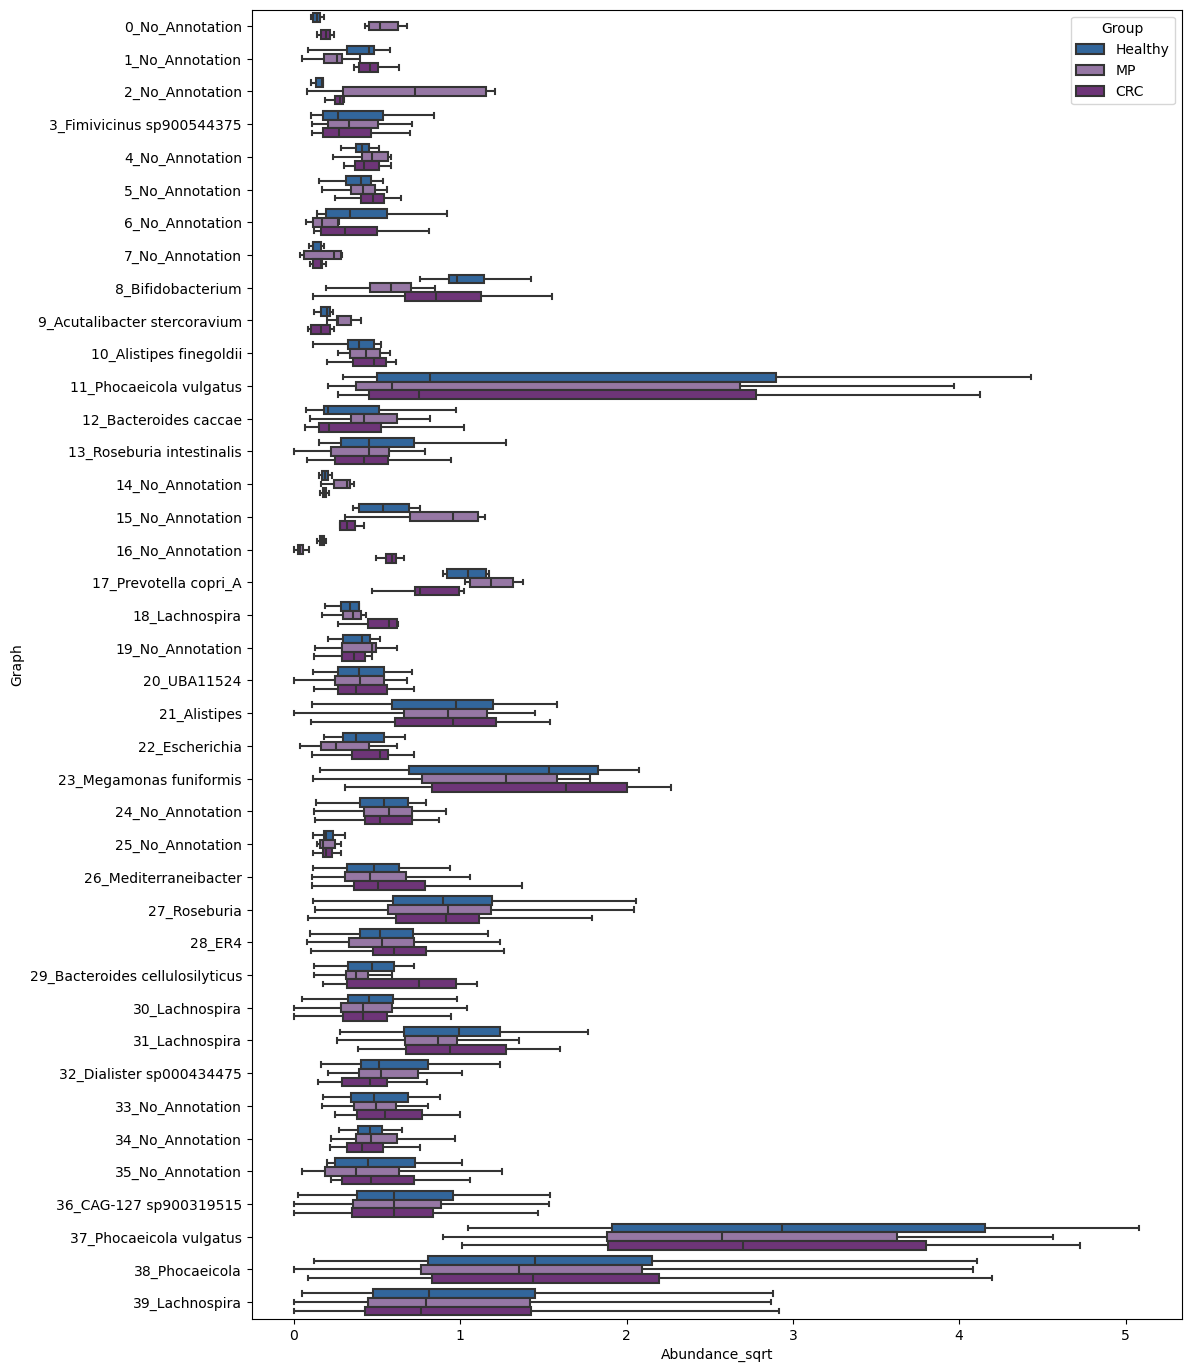

In [47]:
# --- Prep: mean abundance per (graph, node, disease_group) like in your friend's script ---
df_plot = (
    node_sample_abundance_df
    .dropna(subset=["abundance"]) # ignore rows with unkown disease group
    .loc[node_sample_abundance_df["disease_group"] != "unknown", ["graph_name", "node_id", "disease_group", "abundance"]]
    .groupby(["graph_name", "node_id", "disease_group"], as_index=False, observed=True)["abundance"]
    .mean()
    .rename(columns={"graph_name": "Graph", "node_id": "Node", "disease_group": "Group", "abundance": "Abundance"})
)

df_plot["Abundance_sqrt"] = np.sqrt(df_plot["Abundance"].clip(lower=0))

# --- Ordering (sort graphs by numeric id prefix before first "_") ---
graph_order = sorted(df_plot["Graph"].astype(str).unique(), key=lambda x: int(str(x).split("_", 1)[0]))

# --- Hue order (use what exists, but keep the familiar order if present) ---
preferred_hue_order = ["Healthy", "MP", "CRC"]
hue_order = [g for g in preferred_hue_order if g in set(df_plot["Group"].astype(str))] + \
            [g for g in sorted(set(df_plot["Group"].astype(str))) if g not in preferred_hue_order]

# --- Palette (fallback to seaborn default if you have other groups) ---
disease_palette = {"Healthy": "#2166ac", "CRC": "#762a83", "MP": "#9970ab"}
palette = {g: disease_palette[g] for g in hue_order if g in disease_palette}

# --- Plot ---
plt.figure(figsize=(12,17))
ax = sns.boxplot(
    data=df_plot,
    y="Graph",
    x="Abundance_sqrt",
    hue="Group",
    order=graph_order,
    hue_order=hue_order,
    palette=palette if len(palette) == len(hue_order) else None,
    linewidth=1.5,
    showfliers=False,
)


ax.set_title("Node Abundance per Graph by Disease Group")
ax.set_xlabel("Square Root Mean RPKM per Node")
ax.set_ylabel("Graph")

# alternating row shading
for i in range(len(graph_order)):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, facecolor="gray", alpha=0.15, zorder=0)

ax.legend(title="Disease group", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.xaxis.grid(True, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

In [41]:
# find out how many rows each disease group has
node_sample_abundance_df.groupby("disease_group").size()

/var/folders/21/f8bdlnrn6nd5jf2zc89bvz3m0000gn/T/ipykernel_49023/889809369.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  node_sample_abundance_df.groupby("disease_group").size()


disease_group
CRC        723969
Healthy    819747
MP         188739
unknown     25870
dtype: int64